In [12]:
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# Notice: We removed the dark_background style to keep the canvas white

def pareto_front_fast(psnr, lpips):
    points = np.column_stack([psnr, lpips])
    points = points[np.argsort(-points[:, 0])]
    front = [points[0]]
    best_lpips = points[0, 1]
    for p in points[1:]:
        if p[1] < best_lpips:
            front.append(p)
            best_lpips = p[1]
    front = np.array(front)
    return front[:, 0], front[:, 1]


def get_raw_curve(event_acc, distortion_tag, perception_tag, max_step=30000):
    dist_data = {e.step: e.value for e in event_acc.Scalars(distortion_tag) if e.step <= max_step}
    perc_data = {e.step: e.value for e in event_acc.Scalars(perception_tag) if e.step <= max_step}
    common_steps = sorted(set(dist_data.keys()) & set(perc_data.keys()))
    psnr_vals = [dist_data[s] for s in common_steps]
    lpips_vals = [perc_data[s] for s in common_steps]
    return np.array(psnr_vals), np.array(lpips_vals)


def plot_pareto_front(experiments, distortion_tag, perception_tag, max_step=30000):
    # --- Load & build curves ---
    curves = {}
    for log_dir, label in experiments:
        ea = EventAccumulator(log_dir)
        ea.Reload()
        curves[label] = get_raw_curve(ea, f'metrics/Set14/{distortion_tag}', f'metrics/Set14/{perception_tag}', max_step)

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 8))
    all_texts = []

    # --- TWEAK: Switched to 'Dark2' palette for deep, readable colors on a white background ---
    colors = plt.cm.tab20b(np.linspace(0, 1, len(curves)))

    for i, (label, (psnr_vals, lpips_vals)) in enumerate(curves.items()):
        psnr_f, lpips_f = pareto_front_fast(psnr_vals, lpips_vals)

        ax.plot(psnr_f, lpips_f, marker='o', markersize=6, linestyle='--',
                alpha=0.8, label=label, color=colors[i])

        for p, l in zip(psnr_f, lpips_f):
            txt = ax.text(p, l, f'{p:.2f}, {l:.3f}', fontsize=8, color=colors[i])
            all_texts.append(txt)

    adjust_text(
        all_texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle='->',
            # --- TWEAK: Changed back to a darker gray so arrows don't disappear against the white ---
            color='dimgray',
            lw=0.5,
            alpha=0.7,
            shrinkA=8,
            shrinkB=2,
        ),
        expand_points=(1.5, 1.5),
        force_text=(0.5, 0.5),
    )

    ax.invert_xaxis()
    ax.set_xlabel('Iškraipymas (PSNR ↑)')
    ax.set_ylabel(f'Suvokimas ({perception_tag.upper()} ↓)')
    ax.set_title('Suvokimo-iškraipymo kompromisas (Set14)')

    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend()
    fig.tight_layout()
    plt.show()

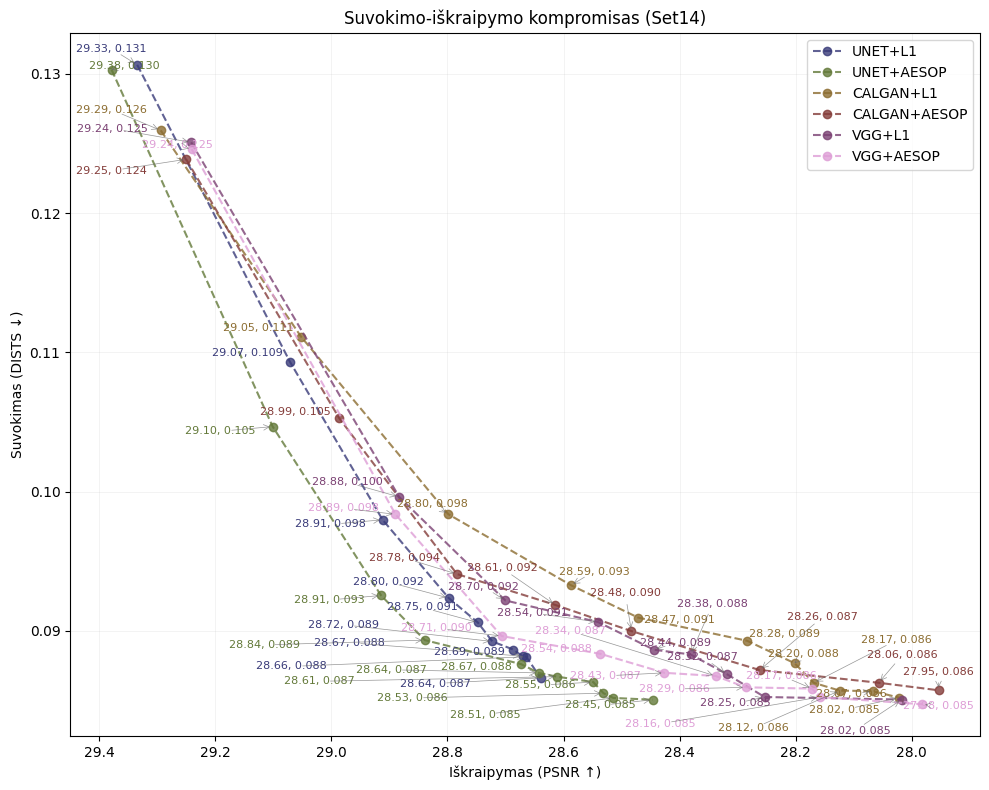

In [13]:
plot_pareto_front(
    experiments=[
        ("../data/training-logs/method-comparison/baseline_l1", "UNET+L1"),
        ("../data/training-logs/method-comparison/baseline_aesop", "UNET+AESOP"),
        ("../data/training-logs/method-comparison/calgan_l1", "CALGAN+L1"),
        ("../data/training-logs/method-comparison/calgan_aesop", "CALGAN+AESOP"),
        ("../data/training-logs/method-comparison/vgg_l1", "VGG+L1"),
        ("../data/training-logs/method-comparison/vgg_aesop", "VGG+AESOP"),
    ],
    distortion_tag='psnr',
    perception_tag='dists'
)

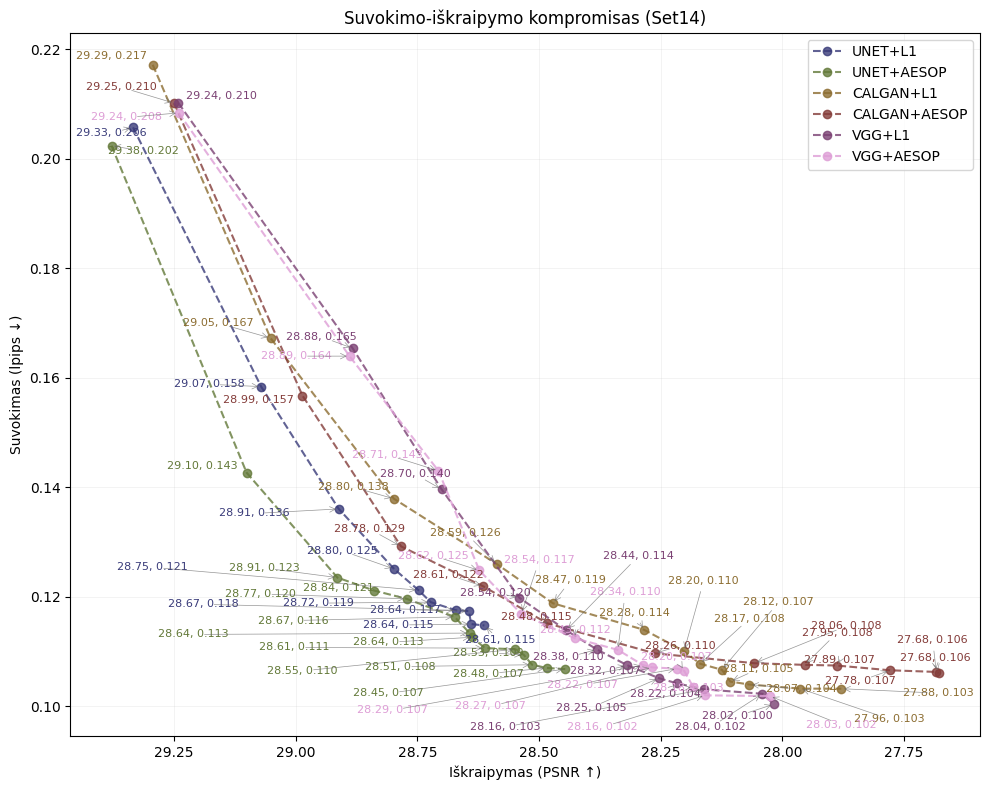

In [11]:
plot_pareto_front(
    experiments=[
        ("../data/training-logs/method-comparison/baseline_l1", "UNET+L1"),
        ("../data/training-logs/method-comparison/baseline_aesop", "UNET+AESOP"),
        ("../data/training-logs/method-comparison/calgan_l1", "CALGAN+L1"),
        ("../data/training-logs/method-comparison/calgan_aesop", "CALGAN+AESOP"),
        ("../data/training-logs/method-comparison/vgg_l1", "VGG+L1"),
        ("../data/training-logs/method-comparison/vgg_aesop", "VGG+AESOP"),
    ],
    distortion_tag='psnr',
    perception_tag='lpips'
)